##Machine Learning: Utilização de Autograd e Otimização de Parâmetros

Autor: Leandro Belo de Almeida Gomes

Objetivo: Neste estudo, implemento um ciclo completo de Machine Learning onde o modelo aprende de forma autônoma. Diferente dos casos anteriores, utilizamos o motor Autograd do PyTorch para ajustar os pesos ($W$) e o viés ($b$) via descida de gradiente, partindo de valores aleatórios até a convergência dos resultados.

##1. Configuração de Hiperparâmetros e Hardware
Definimos o dispositivo de processamento (GPU/CPU) para garantir agnosticismo de hardware. Estabelecemos uma Taxa de Aprendizado (Learning Rate) de 0.01, um valor equilibrado para garantir que a atualização dos pesos seja estável, evitando a divergência do erro (Loss).

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
learning_rate = 0.01
epochs = 500

##2. Arquitetura do Modelo (POO - Programação Orientada a Objetos)
Implementamos a estrutura do neurônio utilizando a classe nn.Module. Esta abordagem é o padrão da indústria para o desenvolvimento de Deep Learning, pois encapsula a lógica do Forward Pass e facilita a escalabilidade para arquiteturas de redes neurais mais complexas.

In [ ]:
class PerceptronSimples(nn.Module):
    def __init__(self, input_dim=2):
        super(PerceptronSimples, self).__init__()
        self.linear = nn.Linear(in_features=input_dim, out_features=1)

    def forward(self, x):
        return self.linear(x)

modelo = PerceptronSimples().to(device)

##3. Definição da Função de Custo e Otimizador
Convertemos as entradas e os gabaritos (Labels) em tensores. Nesta etapa, garantimos que os dados e o modelo residam no mesmo dispositivo de hardware, prevenindo erros de latência e garantindo a eficiência das operações matriciais.

In [ ]:
# Dados de entrada e Gabarito (Labels)
pontos_lista = [[1.0, 2.0], [3.0, 4.0], [5.0, 1.0]]
labels_lista = [[1.0], [1.0], [0.0]]

# Convertendo para Tensores e enviando para o hardware correto
pontos = torch.tensor(pontos_lista, dtype=torch.float32).to(device)
labels = torch.tensor(labels_lista, dtype=torch.float32).to(device)

In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(modelo.parameters(), lr=learning_rate)

##4. Definição da Função de Custo e Algoritmo de Otimização
Utilizamos o MSELoss (Erro Quadrático Médio) para quantificar a distância entre as predições e os labels. O otimizador SGD (Gradiente Descendente Estocástico) é configurado para gerenciar a atualização dos parâmetros do modelo com base nos gradientes calculados automaticamente.

In [ ]:
historico_loss = []

for epoch in range(epochs):
    outputs = modelo(pontos) # Agora 'pontos' existe!
    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    historico_loss.append(loss.item())

    if (epoch + 1) % 50 == 0:
        print(f'Época [{epoch+1}/{epochs}], Erro: {loss.item():.6f}')

Época [50/500], Erro: 0.019837
Época [100/500], Erro: 0.016751
Época [150/500], Erro: 0.014160
Época [200/500], Erro: 0.011971
Época [250/500], Erro: 0.010120
Época [300/500], Erro: 0.008555
Época [350/500], Erro: 0.007232
Época [400/500], Erro: 0.006114
Época [450/500], Erro: 0.005169
Época [500/500], Erro: 0.004369


##5. Avaliação de Desempenho e Curva de Aprendizado
A visualização da evolução do erro permite validar a saúde do modelo. Uma curva de Loss descendente e suave confirma que o otimizador encontrou o caminho correto para o mínimo global, resultando em um modelo capaz de realizar predições precisas.

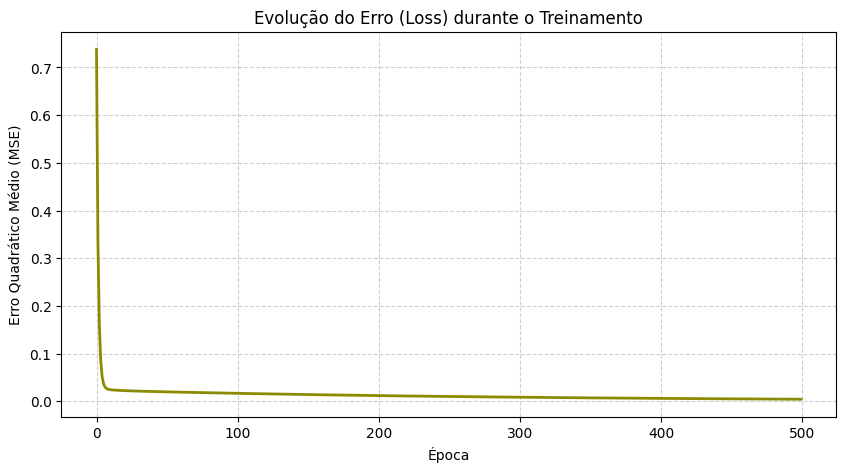

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(historico_loss, color='#8B8B00', linewidth=2) # Tom oliva/mostarda
plt.title('Evolução do Erro (Loss) durante o Treinamento')
plt.xlabel('Época')
plt.ylabel('Erro Quadrático Médio (MSE)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
!pytest tests/

============================= test session starts ==============================
platform linux -- Python 3.12.13, pytest-8.4.2, pluggy-1.6.0
rootdir: /content
plugins: anyio-4.13.0, typeguard-4.5.1, langsmith-0.7.34
collected 3 items                                                              

tests/test_model.py ...                                                  [100%]

============================== 3 passed in 3.71s ===============================
